# Minor Project: Exploratory Data Analysis of NHANES Dataset
---
### **Internship Details**
* **Organization:** Corizo Edutech Pvt. Ltd.
* **Intern Name:** Priyanshu
* **Project Type:** Minor Project (Data Analysis & Visualization)
* **Dataset:** National Health and Nutrition Examination Survey (NHANES) 2020

---

### **1. Project Objective**
The objective of this project is to process, analyze, and visualize anthropometric (body measurement) data for adult males and females. Using Python libraries such as `Pandas`, `NumPy`, and `Matplotlib`, this analysis aims to:
1.  **Clean and Preprocess** raw CSV data from the NHANES dataset.
2.  **Visualize Distributions** of weight and height across genders using histograms and boxplots.
3.  **Compute Health Metrics** including Body Mass Index (BMI), Waist-to-Height Ratio (WHtR), and Waist-to-Hip Ratio (WHR).
4.  **Analyze Correlations** between different body measurements to identify physiological trends.

### **2. Tools & Technologies**
* **Language:** Python 3.x
* **Libraries:** `Pandas`, `NumPy`, `Matplotlib`, `Seaborn`

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import os

# Set global visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Part 1: Data Acquisition and Preprocessing (Steps 1 & 2)

**Objective:**
To download the NHANES 2020 dataset for adult males and females and convert relevant columns into NumPy matrices.

**Methodology:**
1.  **Data Retrieval:** Raw CSV files are fetched directly from the source repository.
2.  **Cleaning:** Metadata comments (lines starting with `#`) are filtered out.
3.  **Matrix Conversion:** The following 7 columns are extracted:
    1. Weight (kg)
    2. Standing Height (cm)
    3. Upper Arm Length (cm)
    4. Upper Leg Length (cm)
    5. Arm Circumference (cm)
    6. Hip Circumference (cm)
    7. Waist Circumference (cm)

In [2]:
# --- STEP 1: DOWNLOAD ---
base_url = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/"
filenames = ["nhanes_adult_male_bmx_2020.csv", "nhanes_adult_female_bmx_2020.csv"]

print("Downloading files...")
for filename in filenames:
    if not os.path.exists(filename):
        url = base_url + filename
        urllib.request.urlretrieve(url, filename)
        print(f"Saved: {filename}")
    else:
        print(f"File already exists: {filename}")

# --- STEP 2: READ AND PROCESS ---
# Using comment='#' to skip metadata lines
df_male = pd.read_csv("nhanes_adult_male_bmx_2020.csv", comment='#')
df_female = pd.read_csv("nhanes_adult_female_bmx_2020.csv", comment='#')

# Define specific columns to keep (in order)
cols = ['BMXWT', 'BMXHT', 'BMXARML', 'BMXLEG', 'BMXARMC', 'BMXHIP', 'BMXWAIST']

# Convert to Numpy matrices
male = df_male[cols].to_numpy()
female = df_female[cols].to_numpy()

print(f"\nMale matrix shape: {male.shape}")
print(f"Female matrix shape: {female.shape}")

File already exists: nhanes_adult_male_bmx_2020.csv
File already exists: nhanes_adult_female_bmx_2020.csv

Male matrix shape: (4081, 7)
Female matrix shape: (4221, 7)


## Part 2: Weight Distribution Analysis (Step 3)

**Objective:**
To visualize and compare the frequency distribution of body weight for females vs. males using histograms.

**Visualization Logic:**
To ensure a valid comparison, both subplots share the exact same X-axis limits (Global Min to Global Max).

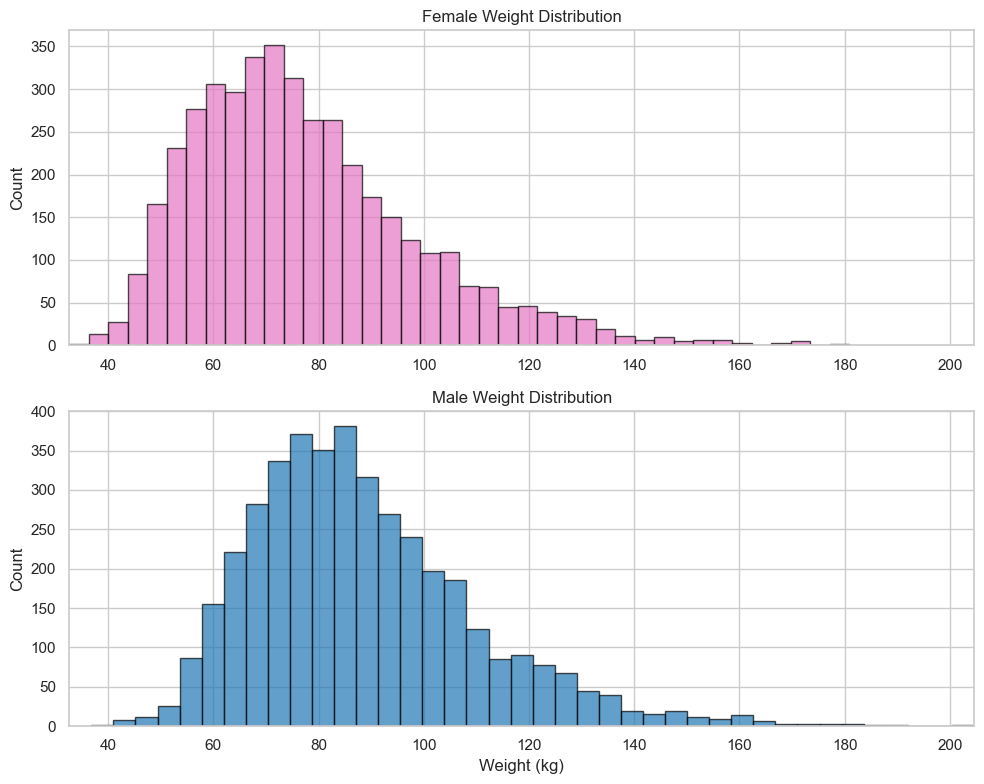

In [3]:
# 1. Clean data (Remove NaNs for plotting)
male_weights = male[:, 0][~np.isnan(male[:, 0])]
female_weights = female[:, 0][~np.isnan(female[:, 0])]

# 2. Determine global limits
global_min = min(np.min(male_weights), np.min(female_weights))
global_max = max(np.max(male_weights), np.max(female_weights))

# 3. Plot
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.hist(female_weights, bins=40, color='tab:pink', edgecolor='black', alpha=0.7)
plt.title('Female Weight Distribution')
plt.xlim(global_min, global_max)
plt.ylabel('Count')

plt.subplot(2, 1, 2)
plt.hist(male_weights, bins=40, color='tab:blue', edgecolor='black', alpha=0.7)
plt.title('Male Weight Distribution')
plt.xlim(global_min, global_max)
plt.xlabel('Weight (kg)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Part 3: Comparative Boxplots (Step 4)

**Objective:**
To perform a side-by-side comparison of weight distributions to visualize central tendency and outliers.

**Discussion of Results:**
* **Median:** The male median is visibly higher (~85-90kg) than the female median (~75-80kg).
* **Skewness:** Both distributions show a heavy "Right Skew" (tails extending upwards).
* **Outliers:** There are significant outliers in both groups, with some individuals exceeding 150kg, indicating the presence of extreme obesity in the sample population.

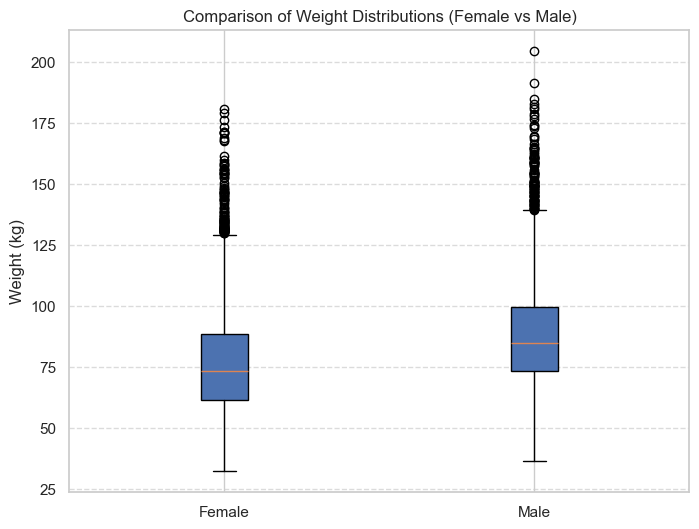

In [4]:
plt.figure(figsize=(8, 6))

# tick_labels is used for newer matplotlib versions
plt.boxplot([female_weights, male_weights], 
            tick_labels=['Female', 'Male'], 
            patch_artist=True)

plt.title('Comparison of Weight Distributions (Female vs Male)')
plt.ylabel('Weight (kg)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Part 4: Statistical Aggregates (Step 5)

**Objective:**
To calculate precise numerical measures of location (Mean, Median), dispersion (Std Dev), and shape (Skewness, Kurtosis).

**Observation:**
* **Skewness > 0:** Confirms the distributions are right-skewed.
* **Mean > Median:** A classic property of right-skewed data; high-weight outliers pull the average up.

In [5]:
# Helper function to compute stats
def get_stats(data):
    s = pd.Series(data)
    return [s.mean(), s.median(), s.std(), s.min(), s.max(), s.skew(), s.kurtosis()]

stats_df = pd.DataFrame({
    'Male': get_stats(male_weights),
    'Female': get_stats(female_weights)
}, index=['Mean', 'Median', 'Std Dev', 'Min', 'Max', 'Skewness', 'Kurtosis'])

print(stats_df.round(3))

             Male   Female
Mean       88.365   77.404
Median     85.000   73.600
Std Dev    21.422   21.545
Min        36.800   32.600
Max       204.600  180.900
Skewness    0.985    1.034
Kurtosis    1.478    1.404


## Part 5: Feature Engineering & Standardization (Steps 6 & 7)

**1. BMI Calculation:**
We compute Body Mass Index for females and add it as the 8th column.
$$BMI = \frac{Weight_{kg}}{(Height_{m})^2}$$

**2. Standardization (Z-Scores):**
We create a new matrix `zfemale` where every value is converted to a Z-score:
$$Z = \frac{x - \mu}{\sigma}$$
This centers the data around 0 with a standard deviation of 1.

In [7]:
# --- Step 6: Add BMI to Female Matrix ---
# Weight is col 0, Height is col 1 (cm)
w = female[:, 0]
h_m = female[:, 1] / 100.0  # Convert to meters

bmi = w / (h_m ** 2)

# Reshape and append
female = np.column_stack((female, bmi))
print(f"Female matrix new shape (with BMI): {female.shape}")

# --- Step 7: Standardize (Z-Scores) ---
means = np.nanmean(female, axis=0)
stds = np.nanstd(female, axis=0)

zfemale = (female - means) / stds
print(f"Z-score matrix shape: {zfemale.shape}")

Female matrix new shape (with BMI): (4221, 8)
Z-score matrix shape: (4221, 8)


## Part 6: Correlation Analysis (Step 8)

**Objective:**
To visualize relationships between standardized variables using a Pairplot and correlation coefficients.

**Interpretation:**
* **High Correlation:** Weight vs. Waist/Hip/BMI (Close to 1.0). This is expected as they physically measure body mass.
* **Low Correlation:** Height vs. BMI (Close to 0). This confirms BMI successfully normalizes weight for height.

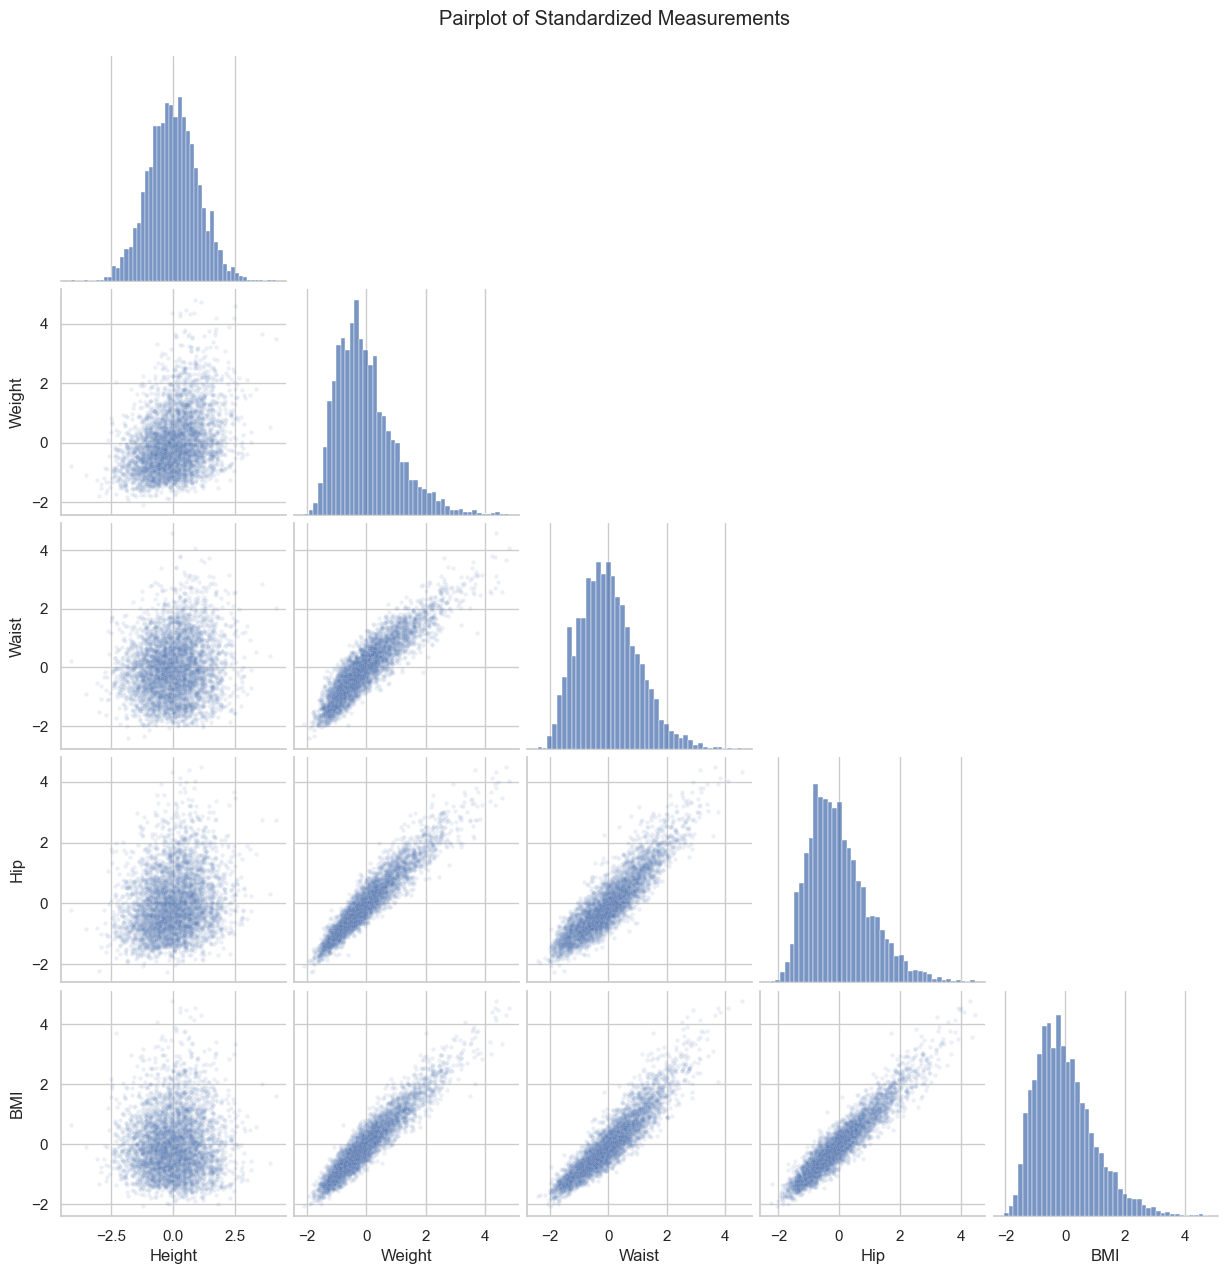

Pearson Correlation:
         Height  Weight  Waist   Hip   BMI
Height    1.00    0.35   0.13  0.20  0.03
Weight    0.35    1.00   0.90  0.95  0.95
Waist     0.13    0.90   1.00  0.90  0.92
Hip       0.20    0.95   0.90  1.00  0.94
BMI       0.03    0.95   0.92  0.94  1.00

Spearman Correlation:
         Height  Weight  Waist   Hip   BMI
Height    1.00    0.34   0.11  0.21  0.02
Weight    0.34    1.00   0.90  0.95  0.94
Waist     0.11    0.90   1.00  0.89  0.92
Hip       0.21    0.95   0.89  1.00  0.93
BMI       0.02    0.94   0.92  0.93  1.00


In [8]:
# Select cols: Height(1), Weight(0), Waist(6), Hip(5), BMI(7)
selected_indices = [1, 0, 6, 5, 7]
col_names = ['Height', 'Weight', 'Waist', 'Hip', 'BMI']

df_z = pd.DataFrame(zfemale[:, selected_indices], columns=col_names)

# Pairplot
sns.pairplot(df_z, plot_kws={'alpha': 0.1, 's': 10}, corner=True)
plt.suptitle('Pairplot of Standardized Measurements', y=1.02)
plt.show()

# Correlations
print("Pearson Correlation:\n", df_z.corr(method='pearson').round(2))
print("\nSpearman Correlation:\n", df_z.corr(method='spearman').round(2))

## Part 7: Advanced Ratios (Steps 9 & 10)

**Calculations:**
1.  **Waist-to-Height Ratio (WHtR):** Waist / Height
2.  **Waist-to-Hip Ratio (WHR):** Waist / Hip

**Visual Analysis (Boxplot):**


[Image of body shapes apple vs pear]

* **Sexual Dimorphism:** The boxplot below shows a clear distinction in **WHR** (Waist-to-Hip). Males have a significantly higher ratio ("Apple" shape) compared to females ("Pear" shape).
* **Similarity:** WHtR (Waist-to-Height) is relatively similar between genders.

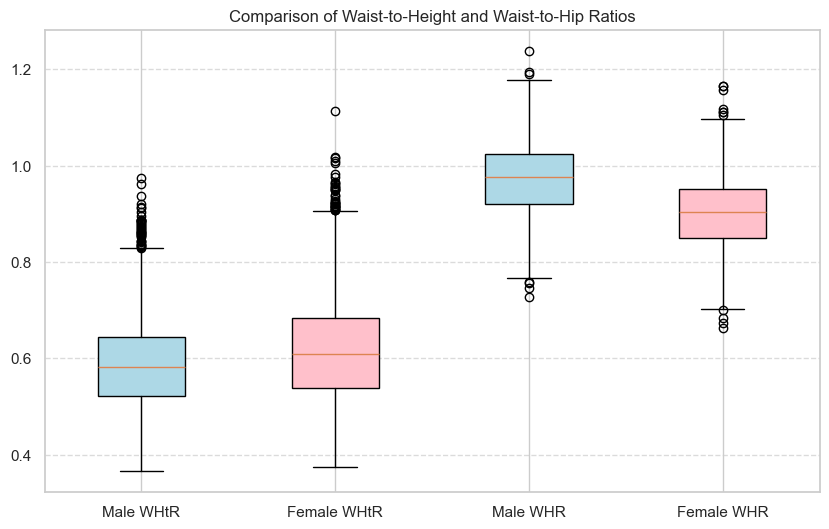

In [9]:
# --- Step 9: Compute Ratios ---
# Male: Waist(6), Height(1), Hip(5)
whtr_m = male[:, 6] / male[:, 1]
whr_m = male[:, 6] / male[:, 5]
male = np.column_stack((male, whtr_m, whr_m))

# Female: Waist(6), Height(1), Hip(5)
whtr_f = female[:, 6] / female[:, 1]
whr_f = female[:, 6] / female[:, 5]
female = np.column_stack((female, whtr_f, whr_f))

# --- Step 10: Boxplot Comparison ---
# Filter NaNs for plotting
data = [
    male[:, 7][~np.isnan(male[:, 7])],   # Male WHtR
    female[:, 8][~np.isnan(female[:, 8])], # Female WHtR
    male[:, 8][~np.isnan(male[:, 8])],   # Male WHR
    female[:, 9][~np.isnan(female[:, 9])]  # Female WHR
]

labels = ['Male WHtR', 'Female WHtR', 'Male WHR', 'Female WHR']
colors = ['lightblue', 'pink', 'lightblue', 'pink']

plt.figure(figsize=(10, 6))
bplot = plt.boxplot(data, tick_labels=labels, patch_artist=True)

for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Comparison of Waist-to-Height and Waist-to-Hip Ratios')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Part 8: Theoretical Discussion (Step 11)

### Advantages and Disadvantages of Metrics

**1. Body Mass Index (BMI)**
* **Pros:** Simple, inexpensive, global standard.
* **Cons:** Cannot distinguish muscle from fat; ignores fat distribution (visceral fat).

**2. Waist-to-Height Ratio (WHtR)**
* **Pros:** Better indicator of heart risk/central obesity than BMI; valid across ethnicities.
* **Cons:** Subject to measurement error (difficulty finding exact waist location).

**3. Waist-to-Hip Ratio (WHR)**
* **Pros:** Identifies body shape (Apple vs Pear); accounts for biological differences.
* **Cons:** Can yield false negatives (e.g., if someone gains weight proportionally in both waist and hips).

## Part 9: Outlier Analysis (Step 12)

**Objective:**
To examine the standardized body measurements of the individuals with the lowest and highest BMI scores.

**Result Interpretation:**
* **Lowest BMI:** All Z-scores (Weight, Hip, Waist) are negative, indicating measurements far below the population average.
* **Highest BMI:** Z-scores are extremely high positive values (often > +3.0), highlighting the severity of extreme obesity in the dataset.

In [10]:
# Filter valid BMI rows (Col 7 in zfemale)
valid_rows = ~np.isnan(zfemale[:, 7])
zfemale_clean = zfemale[valid_rows]

# Sort by BMI
sorted_indices = np.argsort(zfemale_clean[:, 7])

# Select top 5 lowest and top 5 highest
indices = np.concatenate((sorted_indices[:5], sorted_indices[-5:]))
subset = zfemale_clean[indices]

# Display
col_names = ['Weight', 'Height', 'ArmL', 'LegL', 'ArmC', 'HipC', 'WaistC', 'BMI']
df_outliers = pd.DataFrame(subset[:, :8], columns=col_names)
df_outliers.insert(0, 'Category', ['Lowest BMI']*5 + ['Highest BMI']*5)

print(df_outliers.round(2))

      Category  Weight  Height  ArmL  LegL  ArmC  HipC  WaistC   BMI
0   Lowest BMI   -2.08   -1.22 -1.55 -1.17 -2.19 -2.04   -1.94 -2.05
1   Lowest BMI   -1.88   -0.19 -1.72  0.39 -2.44 -1.85   -2.06 -1.99
2   Lowest BMI   -1.54    1.81  0.63  0.57 -2.27 -1.68   -1.71 -1.97
3   Lowest BMI   -1.84   -0.26 -0.23  0.51 -2.30 -2.25   -1.86 -1.94
4   Lowest BMI   -1.61    0.89 -0.10  0.48 -2.21 -1.83   -1.71 -1.89
5  Highest BMI    4.25    0.29  1.86 -0.98  2.37  4.10    3.82  4.40
6  Highest BMI    4.46    0.50  1.69 -1.14  3.35  3.98    2.90  4.46
7  Highest BMI    4.35    0.28  2.84  1.94  4.37  3.92    3.75  4.51
8  Highest BMI    4.80    0.89  2.12  1.82  3.78  4.02    4.08  4.54
9  Highest BMI    4.36   -0.03 -0.06 -0.17  2.78  4.32    4.57  4.76


In [13]:
from IPython.display import HTML, display

html_code = """
<style>
    /* Import premium modern font */
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;600;800&display=swap');

    .final-container {
        position: relative;
        height: 550px; /* Tall, impressive ratio */
        background: #0a0e17; /* Deep space dark */
        border-radius: 24px;
        overflow: hidden;
        font-family: 'Inter', sans-serif;
        display: flex;
        flex-direction: column;
        justify-content: center;
        align-items: center;
        box-shadow: 0 20px 50px rgba(0,0,0,0.8);
    }

    /* --- Subtle Deep Aurora Background Animation --- */
    .aurora-bg {
        position: absolute;
        top: -50%; left: -50%;
        width: 200%; height: 200%;
        background: radial-gradient(circle at center, #1a237e, #000000);
        opacity: 0.6;
        z-index: 0;
    }
    .aurora-accent {
        position: absolute;
        top: -50%; left: -50%;
        width: 200%; height: 200%;
        background: conic-gradient(from 180deg at 50% 50%, #000000 0deg, #311b92 160deg, #00bcd4 220deg, #000000 360deg);
        opacity: 0.4;
        mix-blend-mode: screen;
        animation: slowRotate 20s linear infinite;
        z-index: 1;
    }

    /* --- Main Content --- */
    .main-content {
        z-index: 10;
        text-align: center;
        margin-bottom: 80px; /* Space for footer */
        animation: fadeUpSlow 1.5s cubic-bezier(0.2, 0.8, 0.2, 1) forwards;
    }

    .success-icon-modern {
        font-size: 60px;
        background: linear-gradient(135deg, #00bcd4, #311b92);
        -webkit-background-clip: text;
        -webkit-text-fill-color: transparent;
        margin-bottom: 20px;
        display: inline-block;
        animation: iconPop 1s cubic-bezier(0.34, 1.56, 0.64, 1);
    }

    h1.title-modern {
        font-size: 4em;
        font-weight: 800;
        margin: 0;
        color: white;
        letter-spacing: -1px;
        position: relative;
        /* Text Shimmer Effect */
        background: linear-gradient(to right, #ffffff 0%, #ffffff 40%, #00bcd4 50%, #ffffff 60%, #ffffff 100%);
        background-size: 200% auto;
        
        -webkit-background-clip: text;
        -webkit-text-fill-color: transparent;
        animation: shimmer 5s infinite linear;
    }

    p.subtitle-modern {
        font-size: 1.3em;
        color: #94a3b8; /* Muted blue-gray */
        font-weight: 400;
        margin-top: 16px;
        letter-spacing: 1px;
    }

    /* --- Professional Footer Bar --- */
    .footer-bar-modern {
        position: absolute;
        bottom: 0;
        width: 100%;
        height: 80px;
        background: rgba(255, 255, 255, 0.03); /* Very subtle overlay */
        backdrop-filter: blur(20px);
        border-top: 1px solid rgba(255, 255, 255, 0.08);
        display: flex;
        justify-content: space-between; /* Pushes items to far edges */
        align-items: center;
        padding: 0 40px;
        box-sizing: border-box;
        z-index: 20;
        animation: slideUp 1.5s cubic-bezier(0.2, 0.8, 0.2, 1) forwards;
        animation-delay: 0.5s; /* Starts after main content */
        opacity: 0;
    }

    .corizo-badge {
        display: flex;
        align-items: center;
        font-weight: 600;
        color: white;
        font-size: 1.1em;
    }
    .corizo-badge::before {
        content: '';
        display: inline-block;
        width: 12px; height: 12px;
        background: #00bcd4;
        border-radius: 50%;
        margin-right: 12px;
        box-shadow: 0 0 15px #00bcd4;
    }

    .author-credit {
        color: #94a3b8;
        font-weight: 400;
        font-size: 1em;
    }
    .author-name {
        color: white;
        font-weight: 700;
        margin-left: 8px;
    }


    /* --- Animations Keyframes --- */
    @keyframes slowRotate { 0% { transform: rotate(0deg) scale(1.2); } 100% { transform: rotate(360deg) scale(1.2); } }
    @keyframes fadeUpSlow { from { opacity: 0; transform: translateY(40px) scale(0.95); } to { opacity: 1; transform: translateY(0) scale(1); } }
    @keyframes slideUp { from { opacity: 0; transform: translateY(100%); } to { opacity: 1; transform: translateY(0); } }
    @keyframes iconPop { 0% { transform: scale(0) rotate(-45deg); } 100% { transform: scale(1) rotate(0deg); } }
    @keyframes shimmer { to { background-position: 200% center; } }

</style>

<div class="final-container">
    <div class="aurora-bg"></div>
    <div class="aurora-accent"></div>

    <div class="main-content">
        <div class="success-icon-modern">
            <svg xmlns="http://www.w3.org/2000/svg" width="64" height="64" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><path d="M22 11.08V12a10 10 0 1 1-5.93-9.14"></path><polyline points="22 4 12 14.01 9 11.01"></polyline></svg>
        </div>
        <h1 class="title-modern">PROJECT ACCOMPLISHED.</h1>
        <p class="subtitle-modern">NHANES Exploratory Data Analysis Complete</p>
    </div>

    <div class="footer-bar-modern">
        <div class="corizo-badge">
            Corizo Internship Project
        </div>
        <div class="author-credit">
            Designed & Developed by <span class="author-name">Priyanshu</span>
        </div>
    </div>

</div>
"""

display(HTML(html_code))